# CP4 - Regressão Linear
---

## Objetivo
O objetivo deste notebook não é apenas obter um modelo com boas métricas, mas construir uma análise coerente, reproduzível e bem interpretada.

## Resultado final esperado

Consguir avaliar diante a base de dados utilizados usando regressão linear o quanto que vale seu carro utilizado

MUDANÇA:Estimar o valor de um carro usado utilizando regressão linear com base em dados reais de veículos.

## Sobre

Este trabalho foi desenvolvido para o Checkpoint 4 da matéria Data Science e Statistical Computing, do 2º ano de Engenharia de Software. Para mais informações sobre o trabalho, veja nosso repositório no GitHub a partir deste [link](https://youtube.com).

## Licença

Este projeto está licenciado sob a [CC BY-NC 4.0](https://creativecommons.org/licenses/by-nc/4.0/deed.pt) — uso e estudo livres, uso comercial requer autorização prévia do autor.

---
# Desenvolvimento
## 1.Sumário


1.   [Sumário](#1.sumario)
2.   [outro](#1.outro)

---
# Base de dados

## Requisitos

> * Conter uma variável resposta quantitativa contínua.
> * Possuir pelo menos uma variável explicativa com relação plausível com a resposta.
> * Ter, preferencialmente, 100 ou mais observações.
> * Apresentar contexto suficiente para que os resultados possam ser interpretados.
> * Permitir alguma etapa relevante de limpeza, transformação ou organização dos dados.
> * Ter origem identificada e documentação mínima das variáveis.

## Base utilizada

A base de dados escolhida foi a [Used Cars Database](https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data) encontrada no site kaggle.com, a base foi organizada por Austin Reese e também disponível no [GitHub](https://github.com/AustinReese/UsedVehicleSearch).

Os dados foram coletados por meio de *web scraping* — técnica que permite extrair informações diretamente de páginas web, reunindo anúncios de veículos usados publicados no Craigslist nos Estados Unidos.

<details>
<summary><b>Nota O que é o Craigslist?</b></summary>

> Craigslist é um site de classificados americano, fundado em 1995, onde pessoas anunciam de tudo — empregos, imóveis, itens usados e, no caso deste dataset, veículos. Cada cidade/região dos EUA tem sua própria página de anúncios, sem um cadastro centralizado nem preço fixo — os valores são definidos livremente por quem anuncia, o que explica a presença de outliers e inconsistências nos dados.

</details>

<details>
<summary><b>O que é web scraping?</b></summary>

> Web scraping é a técnica de extrair dados automaticamente de páginas web, geralmente usando um programa que acessa o HTML de cada página e coleta as informações desejadas (preço, ano, quilometragem etc.), transformando-as em um formato estruturado como CSV. Diferente de uma API oficial, o scraping depende da estrutura da página no momento da coleta, por isso é mais sujeito a erros de captura e dados inconsistentes.

</details>

# Amostragem

Os dados presentes no arquivo CSV somam um total de 1,34 GB (1.447.955.215 bytes) e 426.880 observações. Nesse tamanho, não é possível carregar o arquivo completo no Google Colab, então utilizaremos uma amostra aleatória, gerada a partir do código abaixo:

```python
import pandas as pd

df = pd.read_csv("sua_tabela_de_dados.csv")

amostra = df.sample(n=numero_de_linhas, random_state=sua_seed)

amostra.to_csv("seu_caminho/amostra_vehicles.csv", index=False)
```

Este script está disponível no repositório do projeto, em `src/utils/collect_sample`, e pode ser reaproveitado em outros projetos. Também disponibilizamos os dois arquivos CSV prontos: o completo (`src/data/vehicles.csv`) e a amostra de 200.000 observações (`src/data/amostra_vehicles.csv`, gerada com `random_state=42`).

Neste notebook, será utilizada apenas a amostra de 200.000 observações.


In [ ]:
# Carregamento do csv de amostra a partir do drive
import pandas as pd
import gdown
import os

# ID do arquivo do Google Drive
file_id = "1RDirUIPhbCCTOtJMI96uG1PH6uxnMD9l"

# URL para download usando gdown
url = f"https://drive.google.com/uc?id={file_id}"

# Caminho local para salvar o arquivo
output_path = "amostra_vehicles.csv"

print(f"Tentando baixar o arquivo do Google Drive: {url}")
# Baixar o arquivo usando gdown, que pode lidar com o aviso de varredura de vírus
try:
    gdown.download(url, output=output_path, quiet=False)
    print(f"Download concluído para {output_path}.")
except Exception as e:
    print(f"Erro durante o download com gdown: {e}")
    print("O download falhou. Não foi possível carregar a tabela.")
    df = pd.DataFrame() # Garante que df seja definido mesmo se o download falhar

# --- Etapa de Diagnóstico e Carregamento do CSV ---
# Verifica se o arquivo foi baixado e seu conteúdo
if os.path.exists(output_path):
    try:
        with open(output_path, 'r', encoding='utf-8') as f:
            first_lines = f.read(500) # Lê os primeiros 500 caracteres

        if "<!DOCTYPE html>" in first_lines.lower():
            print("Erro: O arquivo baixado é uma página HTML de aviso, não o arquivo CSV esperado.")
            print("Isso pode acontecer com arquivos muito grandes ou problemas de permissão/acesso no Google Drive.")
            print("Por favor, verifique as permissões de compartilhamento do arquivo ou tente novamente.")
            os.remove(output_path) # Limpa o arquivo inválido
            df = pd.DataFrame() # Garante que df seja vazio
        else:
            # Se não for HTML, tenta ler o CSV
            df = pd.read_csv(output_path)

            # Mostra o seu tamanho
            print(f"DataFrame carregado com sucesso. Dimensões: {df.shape}")

            # Mostrar primeiras 5 linhas
            print("\nPrimeiras 5 linhas do DataFrame:")
            display(df.head()) # Alterado para display()

    except pd.errors.ParserError as pe:
        print(f"Erro ao ler o arquivo CSV: {pe}")
        print("O arquivo pode estar corrompido ou em um formato inesperado após o download.")
        df = pd.DataFrame() # Garante que df seja vazio
    except Exception as e:
        print(f"Ocorreu um erro inesperado ao processar o arquivo: {e}")
        df = pd.DataFrame() # Garante que df seja vazio
else:
    print("Erro: O arquivo 'amostra_vehicles.csv' não foi encontrado após a tentativa de download.")
    df = pd.DataFrame() # Garante que df seja vazio


Tentando baixar o arquivo do Google Drive: https://drive.google.com/uc?id=1RDirUIPhbCCTOtJMI96uG1PH6uxnMD9l


Downloading...
From (original): https://drive.google.com/uc?id=1RDirUIPhbCCTOtJMI96uG1PH6uxnMD9l
From (redirected): https://drive.google.com/uc?id=1RDirUIPhbCCTOtJMI96uG1PH6uxnMD9l&confirm=t&uuid=df9cdc6a-893b-430b-b549-c8c9fec53474
To: /content/amostra_vehicles.csv
100%|██████████| 680M/680M [00:07<00:00, 88.7MB/s]


Download concluído para amostra_vehicles.csv.
DataFrame carregado com sucesso. Dimensões: (200000, 26)

Primeiras 5 linhas do DataFrame:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7315883828,https://lakeland.craigslist.org/ctd/d/lakeland...,lakeland,https://lakeland.craigslist.org,36990,2017.0,ford,f150 super cab lariat,good,6 cylinders,...,NaN,pickup,white,https://images.craigslist.org/00s0s_lRS7etJoVE...,Carvana is the safer way to buy a car During t...,NaN,fl,28.0400,-81.9600,2021-05-02T15:31:06-0400
1,7314599643,https://quadcities.craigslist.org/ctd/d/waterl...,"quad cities, IA/IL",https://quadcities.craigslist.org,27995,2006.0,chevrolet,corvette,good,8 cylinders,...,NaN,convertible,black,https://images.craigslist.org/00101_aa4DyXpKu0...,2006 *** Chevrolet Corvette Convertible Conver...,NaN,il,42.4778,-92.3661,2021-04-29T18:46:35-0500
2,7308399808,https://littlerock.craigslist.org/ctd/d/clinto...,little rock,https://littlerock.craigslist.org,78423,2015.0,chevrolet,corvette,NaN,8 cylinders,...,NaN,convertible,NaN,https://images.craigslist.org/00A0A_kJsL7mVMCg...,➔ Want to see more pictures?Paste this link to...,NaN,ar,38.4018,-93.7850,2021-04-17T14:01:33-0500
3,7312663807,https://wheeling.craigslist.org/ctd/d/follansb...,northern panhandle,https://wheeling.craigslist.org,14000,2013.0,bmw,328i,NaN,NaN,...,NaN,NaN,NaN,https://images.craigslist.org/00K0K_2oCjTKrjd9...,"**Deals, Deals, Deals** Beautiful 2013 BMW 3-S...",NaN,oh,40.3203,-80.6250,2021-04-25T23:53:42-0400
4,7315368523,https://eugene.craigslist.org/ctd/d/cottage-gr...,eugene,https://eugene.craigslist.org,676,2019.0,chevrolet,suburban ls,NaN,8 cylinders,...,NaN,NaN,black,https://images.craigslist.org/00H0H_3hFsa4lTxO...,2019 Chevrolet Suburban LS Brads Chevy - ☎️ ...,NaN,or,43.7839,-123.0529,2021-05-01T10:04:24-0700


# Exploração dos dados

## Colunas
Antes de começarmos a limpeza dos dados precisamos saber um pouco mais sobre a amostragem da base de dados começando por suas colunas:

In [ ]:
# comando que possibilita ver as colunas do arquivo com seu index e nome
colunas = pd.DataFrame(df.columns, columns=["nome"])
colunas.index.name = "index"
colunas

,nome
index,
0,id
1,url
2,region
3,region_url
4,price
5,year
6,manufacturer
7,model
8,condition



A tabela abaixo descreve todas as colunas originais do dataset **Used Cars Dataset**

| Coluna | Tipo | Unidade / Categorias | Descrição |
|---|---|---|---|
| `id` | Numérica (identificador) | — | Identificador único do anúncio no Craigslist. |
| `url` | Texto | — | Link direto para o anúncio original. |
| `region` | Categórica nominal | Nome da região | Região/cidade dos EUA onde o anúncio foi publicado. |
| `region_url` | Texto | — | Link para a página do Craigslist daquela região. |
| `price` | Numérica contínua | USD (US$) | Preço anunciado do veículo — **variável resposta (y)** deste projeto. |
| `year` | Numérica discreta | Ano | Ano de fabricação do veículo. |
| `manufacturer` | Categórica nominal | Categorias | Fabricante/montadora do veículo (ex: ford, toyota, chevrolet). |
| `model` | Categórica nominal | Categorias | Modelo específico do veículo. |
| `condition` | Categórica ordinal | Categorias | Estado de conservação declarado pelo anunciante (ex: new, excellent, good, fair, salvage). |
| `cylinders` | Categórica ordinal | Categorias | Número de cilindros do motor (ex: 4 cylinders, 6 cylinders). |
| `fuel` | Categórica nominal | Categorias | Tipo de combustível (gas, diesel, hybrid, electric, other). |
| `odometer` | Numérica contínua | Milhas | Quilometragem (em milhas) registrada no veículo. |
| `title_status` | Categórica nominal | Categorias | Situação do documento do veículo (clean, salvage, rebuilt, etc.). |
| `transmission` | Categórica nominal | Categorias | Tipo de câmbio (automatic, manual, other). |
| `VIN` | Texto (identificador) | — | Número de identificação do veículo (chassi), único por unidade fabricada. |
| `drive` | Categórica nominal | Categorias | Tipo de tração (4wd, fwd, rwd). |
| `size` | Categórica ordinal | Categorias | Porte do veículo (ex: compact, mid-size, full-size). |
| `type` | Categórica nominal | Categorias | Tipo de carroceria (sedan, SUV, pickup, coupe, etc.). |
| `paint_color` | Categórica nominal | Categorias | Cor da pintura do veículo. |
| `image_url` | Texto | — | Link para a imagem do anúncio. |
| `description` | Texto livre | — | Descrição em texto escrita pelo anunciante. |
| `county` | Categórica nominal | Categorias | Condado do anúncio (coluna praticamente vazia na base original). |
| `state` | Categórica nominal | Sigla (2 letras) | Estado americano onde o veículo está anunciado. |
| `lat` | Numérica contínua | Graus decimais | Latitude aproximada do anúncio. |
| `long` | Numérica contínua | Graus decimais | Longitude aproximada do anúncio. |
| `posting_date` | Data/hora | Timestamp | Data e hora de publicação do anúncio. |


## Dados nulos e duplicados
Após sabermos sobre as colunas da tabela é importante sabermos se contem dados que são nulos e se vão realmente impactar em nossa usagem, como também dados duplicados

In [ ]:
#Verificar se contem valores nulos

#Cria Data frame
nulos = pd.DataFrame({
    "Coluna": df.columns,
    "Nulos": df.isnull().sum().values
})

#Retira colunas que não contem valores nulos
nulos = nulos[nulos["Nulos"] > 0]

if nulos.empty:
    print("Não há colunas com valores nulos.")
else:
    print(nulos)

duplicadas = df.duplicated().sum()
print() #print vazio para melhor visualização
print(f"Quantidade de linhas duplicadas: {duplicadas}")

          Coluna   Nulos
5           year     549
6   manufacturer    8238
7          model    2473
8      condition   81456
9      cylinders   83282
10          fuel    1452
11      odometer    2041
12  title_status    3892
13  transmission    1214
14           VIN   75414
15         drive   61061
16          size  143600
17          type   43394
18   paint_color   60784
19     image_url      32
20   description      33
21        county  200000
23           lat    3124
24          long    3124
25  posting_date      32

Quantidade de linhas duplicadas: 0


Diante os dados apresentados,existem varias colunas que contem linhas nulas, exigindo um tratamento adequado para cada uma e tambem não existem linhas duplicadas em nossa amostra onde não vamos precisar alterar.

## Busca de Inconsistências

Nesta etapa, o objetivo é identificar valores que fogem do padrão esperado em cada coluna do dataset. Alguns exemplos do que caracteriza uma inconsistência:

* Uma coluna categórica (ex: `fuel`, `transmission`) receber um valor fora da lista de categorias válidas
* Uma coluna numérica (ex: `price`, `odometer`) receber valores negativos, nulos ou estatisticamente muito distantes da distribuição esperada
* Uma coluna de texto/link (ex: `url`, `image_url`) não seguir o formato esperado (ex: não começar com `http`)
* Uma coluna de ano (ex: `year`) estar fora de um intervalo plausível

Como cada coluna tem uma natureza diferente (numérica contínua, categórica, texto, data), não existe uma única regra que sirva para todas. Por isso, o método de validação foi dividido por **tipo de dado**: cada função abaixo é responsável por checar um tipo específico de coluna, e o resultado é consolidado num relatório único com a quantidade e o percentual de inconsistências por coluna.

In [ ]:
import numpy as np

def checar_numerica_continua(serie, minimo=None, maximo=None):
    """Retorna mask de valores fora do range esperado"""
    serie_numerica = pd.to_numeric(serie, errors='coerce')
    invalido = serie_numerica.isna()
    if minimo is not None:
        invalido |= (serie_numerica < minimo)
    if maximo is not None:
        invalido |= (serie_numerica > maximo)
    return invalido

def checar_outlier_percentil(serie, limite_inferior=0.01, limite_superior=0.99):
    """
    Marca como inconsistente valores fora dos percentis definidos.
    Mais adequado para colunas com grande variação natural, como 'price'.
    """
    serie_numerica = pd.to_numeric(serie, errors='coerce')
    p_baixo = serie_numerica.quantile(limite_inferior)
    p_alto = serie_numerica.quantile(limite_superior)
    invalido = serie_numerica.isna() | (serie_numerica < p_baixo) | (serie_numerica > p_alto)
    return invalido

def checar_categorica(serie, categorias_validas):
    return ~serie.isin(categorias_validas) & serie.notna()

def checar_ano(serie, ano_min=1900, ano_max=2026):
    ano_num = pd.to_numeric(serie, errors='coerce')
    return (ano_num < ano_min) | (ano_num > ano_max) | ano_num.isna()

def checar_url(serie):
    """Verifica se o valor começa com http:// ou https://, sem usar regex"""
    serie_str = serie.astype(str)
    return ~(serie_str.str.startswith('http://') | serie_str.str.startswith('https://'))

def checar_sigla_estado(serie):
    """Espera exatamente 2 letras minusculas (ex: ca, ny)"""
    serie_str = serie.astype(str)

    return ~(
        (serie_str.str.len() == 2) &
        (serie_str.str.isalpha()) &
        (serie_str.str.islower())
    )

def checar_vin(serie):
    """
    VIN válido: 17 caracteres alfanuméricos, sem as letras I, O, Q
    (não usadas em VINs reais por confusão com 1 e 0).
    """
    serie_str = serie.astype(str)
    letras_proibidas = {'I', 'O', 'Q'}

    def vin_valido(valor):
        if len(valor) != 17 or not valor.isalnum():
            return False
        return not any(letra in letras_proibidas for letra in valor.upper())

    invalido = ~serie_str.apply(vin_valido)
    return invalido & serie.notna() & (serie != '')

In [ ]:
relatorio = {}

# price — usa percentil em vez de valor fixo, já que carros variam muito
# (de sucata a colecionador). Só filtra os extremos estatísticos (1% de cada ponta)
relatorio['price'] = checar_outlier_percentil(df['price'], limite_inferior=0.01, limite_superior=0.99)

# year — ano de fabricação dentro de um range plausível
relatorio['year'] = checar_ano(df['year'])

# odometer — quilometragem não pode ser negativa; extremo superior também via percentil
relatorio['odometer'] = checar_outlier_percentil(df['odometer'], limite_inferior=0.0, limite_superior=0.99)

# condition — categórica ordinal fixa
categorias_condition = {'new', 'like new', 'excellent', 'good', 'fair', 'salvage'}
relatorio['condition'] = checar_categorica(df['condition'], categorias_condition)

# fuel
categorias_fuel = {'gas', 'diesel', 'hybrid', 'electric', 'other'}
relatorio['fuel'] = checar_categorica(df['fuel'], categorias_fuel)

# transmission
categorias_transmission = {'automatic', 'manual', 'other'}
relatorio['transmission'] = checar_categorica(df['transmission'], categorias_transmission)

# drive
categorias_drive = {'4wd', 'fwd', 'rwd'}
relatorio['drive'] = checar_categorica(df['drive'], categorias_drive)

# title_status
categorias_title = {'clean', 'salvage', 'rebuilt', 'lien', 'missing', 'parts only'}
relatorio['title_status'] = checar_categorica(df['title_status'], categorias_title)

# state — sigla de 2 letras maiúsculas
relatorio['state'] = checar_sigla_estado(df['state'])

# VIN
relatorio['VIN'] = checar_vin(df['VIN'])

# lat/long — dentro dos limites geográficos dos EUA (aprox.)
relatorio['lat'] = checar_numerica_continua(df['lat'], minimo=18, maximo=72)
relatorio['long'] = checar_numerica_continua(df['long'], minimo=-180, maximo=-65)

# url / region_url / image_url
for col in ['url', 'region_url', 'image_url']:
    relatorio[col] = checar_url(df[col])

In [ ]:
relatorio_sem_nulos = {}

for coluna, mask in relatorio.items():
    # A máscara de inconsistência é combinada com a máscara de não-nulos
    # para garantir que valores nulos não sejam contados como inconsistências.
    mask_sem_nulo = mask & df[coluna].notna()
    relatorio_sem_nulos[coluna] = mask_sem_nulo

# --- Gerar e exibir um resumo das inconsistências COM considerar valores nulos ---
print("--- Relatório de Inconsistências (COM NULOS) ---")

resumo = pd.DataFrame({
    'coluna': list(relatorio.keys()),
    'qtd_inconsistente': [mask.sum() for mask in relatorio.values()],
    'pct_inconsistente': [round(mask.sum() / len(df) * 100, 2) for mask in relatorio.values()]
}).sort_values('qtd_inconsistente', ascending=False)
print(resumo)

print("\n") # Adiciona uma linha em branco para melhor separação

# --- Gerar e exibir um resumo das inconsistências SEM considerar valores nulos ---
print("--- Relatório de Inconsistências (SEM NULOS) ---")

resumo_sem_nulos = pd.DataFrame({
    'coluna': list(relatorio_sem_nulos.keys()),
    'qtd_inconsistente_sem_nulos': [mask.sum() for mask in relatorio_sem_nulos.values()],
    'pct_inconsistente_sem_nulos': [round(mask.sum() / len(df) * 100, 2) for mask in relatorio_sem_nulos.values()]
}).sort_values('qtd_inconsistente_sem_nulos', ascending=False)
print(resumo_sem_nulos)

--- Relatório de Inconsistências (COM NULOS) ---
          coluna  qtd_inconsistente  pct_inconsistente
2       odometer               4014               2.01
11          long               3172               1.59
10           lat               3165               1.58
0          price               1985               0.99
9            VIN                787               0.39
1           year                549               0.27
14     image_url                 32               0.02
6          drive                  0               0.00
5   transmission                  0               0.00
4           fuel                  0               0.00
3      condition                  0               0.00
7   title_status                  0               0.00
8          state                  0               0.00
12           url                  0               0.00
13    region_url                  0               0.00


--- Relatório de Inconsistências (SEM NULOS) ---
          coluna  qt

# Limpeza dos Dados

Com base no relatório de valores nulos e no relatório de inconsistências gerado anteriormente, e considerando que o objetivo final é **prever o preço do carro (`price`)**, foram tomadas as seguintes decisões de limpeza:

* **`county`** está praticamente vazia (200.000 nulos, ou seja, 100% da base) e será descartada da análise por não possuir nenhuma informação relevante.

* **`VIN`** é um identificador único do veículo (chassi), sem valor preditivo direto para o preço, além de ter alta taxa de nulos (75.414) e inconsistências (787 valores fora do padrão esperado). Será descartada.

* **`size`** possui a maior taxa de nulos entre as colunas com algum preenchimento (143.600, ~71,8% da base). Manter essa coluna exigiria imputação em grande escala, o que poderia distorcer o modelo. Será descartada.

* **`id`, `url`, `region_url`, `image_url`** são colunas identificadoras ou de links. Embora possam conter dados (links válidos, IDs únicos), elas não possuem valor preditivo direto para o preço de um veículo e são desnecessárias para a construção do modelo. Serão descartadas.

* **`cylinders`** (83.282 nulos) e **`condition`** (81.456 nulos) têm alto volume de valores ausentes, mas são colunas com forte relação teórica com o preço (motor e estado de conservação impactam diretamente a precificação de um veículo). Em vez de descartar, serão tratadas na etapa de imputação, mantendo a informação disponível para o modelo.

* **`drive`**, **`paint_color`** e **`type`** também apresentam volume relevante de nulos, mas contribuem para explicar o preço (tração, tipo de carroceria e cor influenciam o valor de mercado). Serão mantidas e tratadas na etapa de imputação.

* **Linhas com `price` nulo** serão removidas, já que `price` é a variável resposta (y) do projeto — não é possível treinar ou validar o modelo em registros sem o valor a ser previsto.

* **Linhas com `price` inconsistente** (1.985 registros, fora dos percentis 1%–99% da distribuição) serão removidas, pois representam valores extremos que provavelmente são erro de digitação ou anúncios atípicos (ex: preço R$1 ou valores exageradamente altos), o que distorceria o treinamento do modelo.

* **Linhas com `odometer` inconsistente** serão removidas pelo mesmo motivo — quilometragem é uma das variáveis mais relevantes para prever o preço, e valores extremos/implausíveis prejudicariam a relação entre as variáveis.

* **`lat` e `long`** com valores fora dos limites geográficos dos Estados Unidos (2 e 3 registros, respectivamente) serão removidos. Como o número de casos é muito pequeno, o impacto da remoção é desprezível.

* **`year`, `fuel`, `transmission`, `title_status`, `state`** não apresentaram inconsistências relevantes (0% a 0.30%) e não exigem tratamento adicional além da remoção pontual de nulos, quando aplicável.

---

**Resultados da Limpeza:**

* **Shape original:** (200000, 26)
* **Shape final após limpeza:** (195080, 19)
* **Linhas removidas:** 4920 de 200000
* **Amostra restante:** 97.54%

# Tratamento dos Dados

Diante das decisões de limpeza definidas acima, o tratamento será aplicado da seguinte forma:

* **Remoção de colunas**: `county`, `VIN` e `size` serão removidas por completo do dataset, já que não agregam valor preditivo ao modelo ou possuem taxa de nulos alta demais para uma imputação confiável.

* **Remoção de linhas por `price`**: registros com `price` nulo ou fora do intervalo entre os percentis 1% e 99% serão removidos da base, já que `price` é a variável resposta (y) e não é possível treinar o modelo sem um valor de preço confiável.

* **Remoção de linhas por `odometer`**: registros com `odometer` fora do intervalo entre os percentis 1% e 99% serão removidos, pelo mesmo motivo valores extremos distorceriam a relação entre quilometragem e preço.

* **Remoção de linhas por `lat`/`long`**: registros com latitude fora de 18–72 graus ou longitude fora de -180 a -65 graus serão removidos, por representarem coordenadas fora dos Estados Unidos (provável erro de coleta/parsing).

* **Imputação**: `cylinders`, `condition`, `drive`, `paint_color` e `type` terão seus valores nulos imputados (em vez de removidos), preservando o volume de dados. A estratégia de imputação (moda, categoria "unknown", ou baseada em outras colunas) será definida na etapa seguinte, específica de tratamento de nulos.

* **Sem tratamento adicional**: `year`, `fuel`, `transmission`, `title_status`, `state`, `url`, `region_url` e `image_url` não apresentaram inconsistências relevantes e não exigem tratamento além da remoção pontual de nulos, quando existentes.


In [ ]:
# Cópia de trabalho para não alterar o df original
df_limpo = df.copy()

# ==========================================================
# 1. Remoção de colunas sem valor preditivo ou com nulos excessivos
# ==========================================================

colunas_para_remover = ['county', 'VIN', 'size', 'id', 'url', 'region_url', 'image_url'] # Adicionadas colunas irrelevantes
df_limpo = df_limpo.drop(columns=colunas_para_remover)

print(f"Shape sem remoção das colunas:{df.shape}")
print() # melhor vizualização
print(f"Colunas removidas: {colunas_para_remover}")
print(f"Shape após remoção de colunas: {df_limpo.shape}")

# ==========================================================
# 2. Remoção de linhas com price nulo ou inconsistente
# ==========================================================
# price nulo
df_limpo = df_limpo[df_limpo['price'].notna()]

# price fora dos percentis 1%-99%
p_baixo_price = df['price'].quantile(0.01)
p_alto_price = df['price'].quantile(0.99)
df_limpo = df_limpo[
    (df_limpo['price'] >= p_baixo_price) & (df_limpo['price'] <= p_alto_price)
]

print(f"\nShape após tratamento de price: {df_limpo.shape}")

# ==========================================================
# 3. Remoção de linhas com odometer inconsistente
# ==========================================================
p_baixo_odo = df['odometer'].quantile(0.01)
p_alto_odo = df['odometer'].quantile(0.99)

df_limpo = df_limpo[
    df_limpo['odometer'].isna() |  # mantém nulo (será tratado na imputação, se for o caso)
    ((df_limpo['odometer'] >= p_baixo_odo) & (df_limpo['odometer'] <= p_alto_odo))
]

print(f"Shape após tratamento de odometer: {df_limpo.shape}")

# ==========================================================
# 4. Remoção de linhas com lat/long fora dos EUA
# ==========================================================
df_limpo = df_limpo[
    df_limpo['lat'].isna() | ((df_limpo['lat'] >= 18) & (df_limpo['lat'] <= 72))
]

df_limpo = df_limpo[
    df_limpo['long'].isna() | ((df_limpo['long'] >= -180) & (df_limpo['long'] <= -65))
]

print(f"Shape após tratamento de lat/long: {df_limpo.shape}")

# ==========================================================
# Resumo final
# ==========================================================
print(f"\nShape original: {df.shape}")
print(f"Shape final após limpeza: {df_limpo.shape}")
print(f"Linhas removidas: {df.shape[0] - df_limpo.shape[0]} de {df.shape[0]}")
print(f"Amostra restante: {(df_limpo.shape[0] / df.shape[0] * 100):.2f}%")


Shape sem remoção das colunas:(200000, 26)

Colunas removidas: ['county', 'VIN', 'size', 'id', 'url', 'region_url', 'image_url']
Shape após remoção de colunas: (200000, 19)

Shape após tratamento de price: (198015, 19)
Shape após tratamento de odometer: (195158, 19)
Shape após tratamento de lat/long: (195080, 19)

Shape original: (200000, 26)
Shape final após limpeza: (195080, 19)
Linhas removidas: 4920 de 200000
Amostra restante: 97.54%


# Imputação de Dados

As colunas `cylinders`, `condition`, `drive`, `paint_color` e `type` possuem volume relevante de nulos, mas foram mantidas (ao invés de descartadas) por terem relação plausível com o preço do veículo. Nesta etapa, os valores ausentes serão preenchidos (imputados) em vez de removidos, para preservar o tamanho da amostra.

A estratégia adotada varia conforme a natureza de cada coluna:

* **`cylinders`, `drive`, `type`** — imputados pela **moda agrupada por `manufacturer`**. A lógica é que veículos do mesmo fabricante tendem a compartilhar características técnicas (ex: uma Ford costuma ter um padrão de tração e número de cilindros mais previsível do que a base como um todo). Quando não há moda disponível para o grupo (ex: fabricante também nulo, ou grupo sem nenhum valor preenchido), o valor é preenchido pela **moda global** da coluna.

* **`condition`** — imputada pela **moda global**, já que o estado de conservação depende mais da avaliação subjetiva do anunciante do que de características do fabricante, não fazendo sentido agrupar por `manufacturer`.

* **`paint_color`** — imputada com a categoria **`"unknown"`**, em vez de moda. Cor do veículo é uma característica arbitrária (escolha do comprador/fábrica), sem relação lógica com outras colunas da base — usar a moda aqui inflaria artificialmente uma cor específica (provavelmente branco ou preto) em ~30% dos registros, o que distorceria a variável.

Ao final, é gerado um comparativo de nulos antes/depois para confirmar que a imputação eliminou os valores ausentes dessas colunas

In [ ]:
# ==========================================================
# Imputação de valores nulos
# ==========================================================

# Nulos antes da imputação
colunas_imputar = ['cylinders', 'condition', 'drive', 'paint_color', 'type']
nulos_antes = df_limpo[colunas_imputar].isnull().sum()

def imputar_por_moda_agrupada(df, coluna, coluna_grupo):
    """Preenche nulos com a moda do grupo (ex: manufacturer);
    se o grupo não tiver moda, usa a moda global como fallback."""
    moda_global = df[coluna].mode(dropna=True)
    moda_global = moda_global.iloc[0] if not moda_global.empty else "unknown"

    moda_por_grupo = df.groupby(coluna_grupo)[coluna].transform(
        lambda x: x.mode(dropna=True).iloc[0] if not x.mode(dropna=True).empty else moda_global
    )

    return df[coluna].fillna(moda_por_grupo).fillna(moda_global)

# cylinders, drive, type -> moda por manufacturer, com fallback pra moda global
for col in ['cylinders', 'drive', 'type']:
    df_limpo[col] = imputar_por_moda_agrupada(df_limpo, col, 'manufacturer')

# condition -> moda global
moda_condition = df_limpo['condition'].mode(dropna=True).iloc[0]
df_limpo['condition'] = df_limpo['condition'].fillna(moda_condition)

# paint_color -> categoria "unknown"
df_limpo['paint_color'] = df_limpo['paint_color'].fillna('unknown')

# ==========================================================
# Verificação pós-imputação
# ==========================================================
nulos_depois = df_limpo[colunas_imputar].isnull().sum()

comparativo = pd.DataFrame({
    'nulos_antes': nulos_antes,
    'nulos_depois': nulos_depois
})

print("--- Comparativo de nulos antes/depois da imputação ---")
print(comparativo)
print(f"\nShape final após imputação: {df_limpo.shape}")

--- Comparativo de nulos antes/depois da imputação ---
             nulos_antes  nulos_depois
cylinders          80911             0
condition          78794             0
drive              59239             0
paint_color        59038             0
type               41900             0

Shape final após imputação: (195080, 19)


# Analise exploratória



## Estatísticas descritivas da variável resposta (price)

A variável resposta `price` (preço anunciado, em USD) apresenta média de **US$ 16.881**, mediana de **US$ 13.900** e desvio padrão de **US$ 13.805**. O fato de a média ser bem maior que a mediana já indica assimetria à direita, confirmada pelo coeficiente de assimetria (**skew ≈ 0.87**): há uma cauda de veículos mais caros puxando a média para cima, típico de dados de preço.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Estatísticas descritivas de 'price' (USD):")
print(df_limpo['price'].describe())
print(f"\nAssimetria (skewness): {df_limpo['price'].skew():.2f}")
print(f"Curtose: {df_limpo['price'].kurt():.2f}")

Estatísticas descritivas de 'price' (USD):
count    195080.000000
mean      16881.200815
std       13804.642159
min           0.000000
25%        5950.000000
50%       13900.000000
75%       25990.000000
max       66999.000000
Name: price, dtype: float64

Assimetria (skewness): 0.87
Curtose: 0.24


## Distribuição da variável resposta

O histograma e o boxplot abaixo confirmam a assimetria à direita observada nas estatísticas: a maior parte dos veículos custa entre US$ 6.000 e US$ 26.000 (intervalo entre o 1º e o 3º quartil), mas existe uma cauda de veículos mais caros que se estende até o limite de corte de US$ 66.999 (imposto na limpeza, pelo percentil 99%). O boxplot também evidencia diversos pontos acima do bigode superior, coerente com a assimetria — não são erro de registro, mas o comportamento natural do mercado de usados (carros premium/de baixa quilometragem).

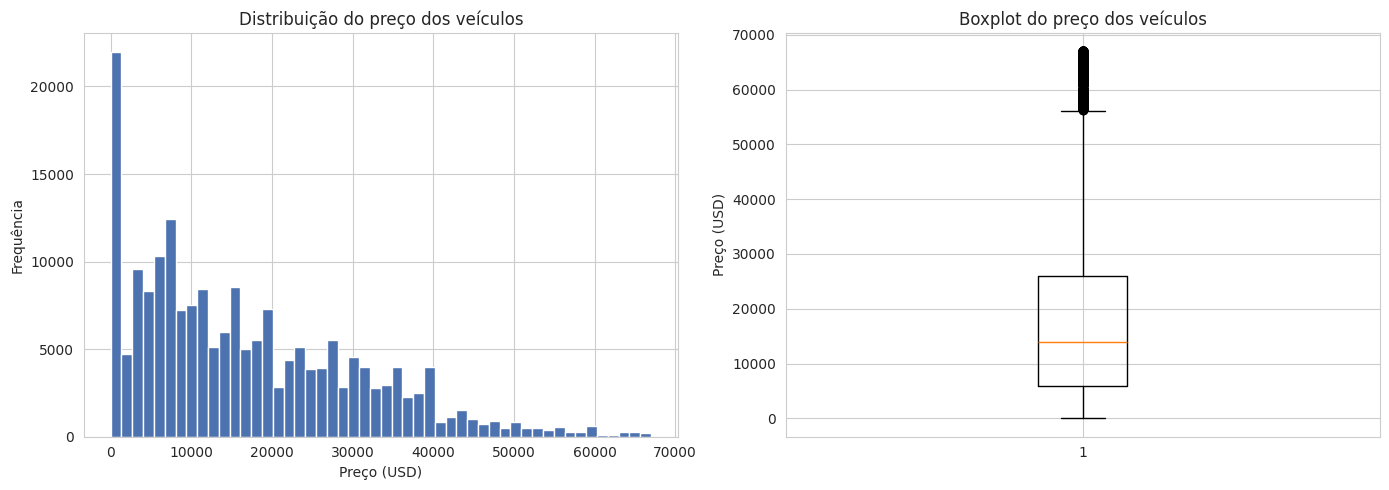

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_limpo['price'], bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_title("Distribuição do preço dos veículos")
axes[0].set_xlabel("Preço (USD)")
axes[0].set_ylabel("Frequência")

axes[1].boxplot(df_limpo['price'], vert=True)
axes[1].set_title("Boxplot do preço dos veículos")
axes[1].set_ylabel("Preço (USD)")

plt.tight_layout()
plt.show()

## Análise dos valores ausentes

Embora a etapa de limpeza tenha tratado `price`, `odometer`, `lat` e `long` (removendo os registros inconsistentes) e imputado `cylinders`, `condition`, `drive`, `paint_color` e `type`, ainda restam valores ausentes em outras colunas que serão usadas ou avaliadas na modelagem: `year` (487), `manufacturer` (7.424), `model` (2.233), `fuel` (1.418), `odometer` (2.025, remanescentes da amostra antes do corte de percentil), `title_status` (3.722), `transmission` (1.187), `lat`/`long` (2.815 cada), além de `description` e `posting_date` (colunas que não entrarão no modelo). Juntas, essas ausências afetam no máximo ~3,8% das linhas por coluna (`manufacturer`), o que é administrável: a decisão será remover as linhas com nulos nas colunas explicativas escolhidas para o modelo na etapa de preparação (3.5), já que o volume é pequeno e a remoção não deve enviesar a amostra de forma relevante.

In [ ]:
nulos_restantes = df_limpo.isnull().sum()
nulos_restantes = nulos_restantes[nulos_restantes > 0].sort_values(ascending=False)
print("Valores ausentes remanescentes após a limpeza/imputação:")
print(nulos_restantes)
print(f"\nPercentual em relação ao total de linhas ({df_limpo.shape[0]}):")
print((nulos_restantes / df_limpo.shape[0] * 100).round(2))

Valores ausentes remanescentes após a limpeza/imputação:
manufacturer    7424
title_status    3722
lat             2815
long            2815
model           2233
odometer        2025
fuel            1418
transmission    1187
year             487
description       33
posting_date      32
dtype: int64

Percentual em relação ao total de linhas (195080):
manufacturer    3.81
title_status    1.91
lat             1.44
long            1.44
model           1.14
odometer        1.04
fuel            0.73
transmission    0.61
year            0.25
description     0.02
posting_date    0.02
dtype: float64


## Dispersão entre a resposta e variáveis quantitativas

O gráfico de `price` versus `odometer` mostra uma relação negativa e com formato de curva (não estritamente linear): a queda de preço é mais acentuada nos primeiros quilômetros e depois se estabiliza, típico de depreciação de veículos — esse é um indício de que vale a pena testar um termo polinomial em `odometer` na etapa de modelagem. Já `price` versus `year` mostra uma relação positiva mais dispersa: carros mais novos tendem a custar mais, mas com grande variabilidade (o preço também depende de fabricante, condição etc.).

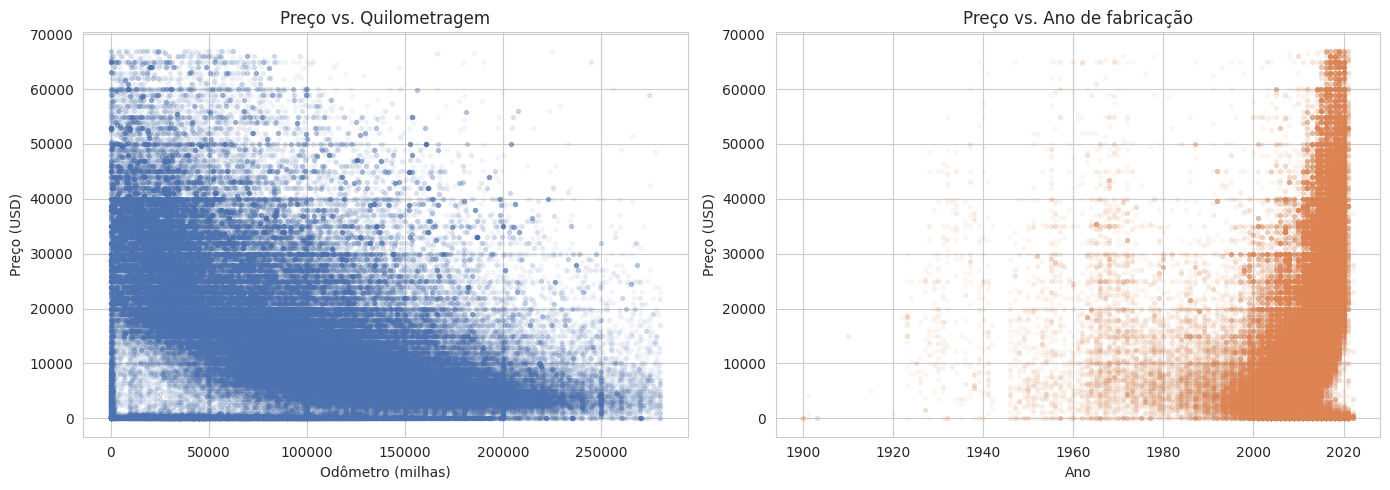

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_limpo['odometer'], df_limpo['price'], alpha=0.05, s=8, color="#4C72B0")
axes[0].set_title("Preço vs. Quilometragem")
axes[0].set_xlabel("Odômetro (milhas)")
axes[0].set_ylabel("Preço (USD)")

axes[1].scatter(df_limpo['year'], df_limpo['price'], alpha=0.05, s=8, color="#DD8452")
axes[1].set_title("Preço vs. Ano de fabricação")
axes[1].set_xlabel("Ano")
axes[1].set_ylabel("Preço (USD)")

plt.tight_layout()
plt.show()

## Correlação entre variáveis quantitativas

A correlação de Pearson confirma o que os gráficos de dispersão sugerem: `odometer` é a variável quantitativa mais associada a `price` (**r ≈ -0.46**, a mais forte da base), seguida por `year` (**r ≈ +0.31**). `lat` e `long` praticamente não têm relação linear com o preço (**r ≈ -0.004** e **-0.04**), o que já indica que localização geográfica bruta (coordenadas) não deve entrar como preditor quantitativo direto — se for usada, faria mais sentido via `state`/`region` como categórica. Não há sinal de multicolinearidade forte entre `year` e `odometer` (**r ≈ -0.32**, moderada e esperada — carros mais novos rodaram menos).

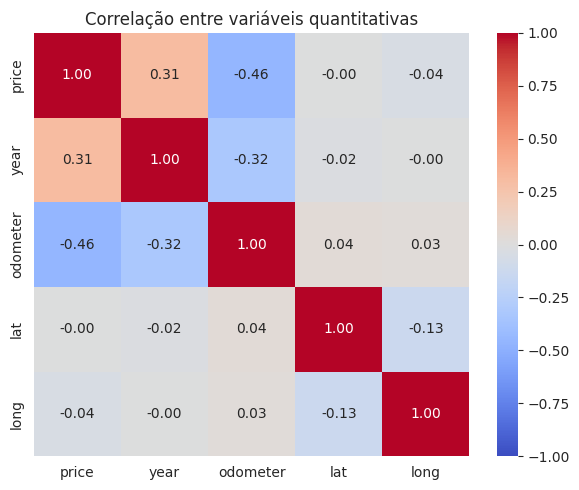

             price      year  odometer       lat      long
price     1.000000  0.306614 -0.455764 -0.004168 -0.039752
year      0.306614  1.000000 -0.322100 -0.017992 -0.001465
odometer -0.455764 -0.322100  1.000000  0.035566  0.026038
lat      -0.004168 -0.017992  0.035566  1.000000 -0.128314
long     -0.039752 -0.001465  0.026038 -0.128314  1.000000


In [ ]:
quant_cols = ['price', 'year', 'odometer', 'lat', 'long']
corr = df_limpo[quant_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlação entre variáveis quantitativas")
plt.tight_layout()
plt.show()

print(corr)

## Análise de variável categórica

Analisando `condition` (estado de conservação declarado pelo anunciante), o preço médio é bem mais baixo para `fair` (US$ 3.852) e `salvage` (US$ 3.750) do que para `good` (US$ 18.204), `excellent` (US$ 13.911), `like new` (US$ 17.045) e `new` (US$ 17.771) — confirmando que condição afeta o preço, como esperado. Note que a ordem entre as categorias "boas" não é perfeitamente monotônica (ex.: `good` aparece com média maior que `new`); isso provavelmente reflete o tamanho desigual das amostras (`new` tem apenas 590 observações contra 134.944 de `good`) e a confusão com outras variáveis (tipo de veículo, fabricante), não uma relação inversa real entre condição e preço.

            count          mean   median           std
condition                                             
good       134944  18203.846047  15990.0  14308.609554
new           590  17771.347458  12649.5  17915.867304
like new     9591  17045.377229  13500.0  14010.758126
excellent   46756  13910.967362  10970.0  11545.769324
fair         2937   3852.190671   2800.0   3904.000392
salvage       262   3749.893130   1900.0   4823.950564


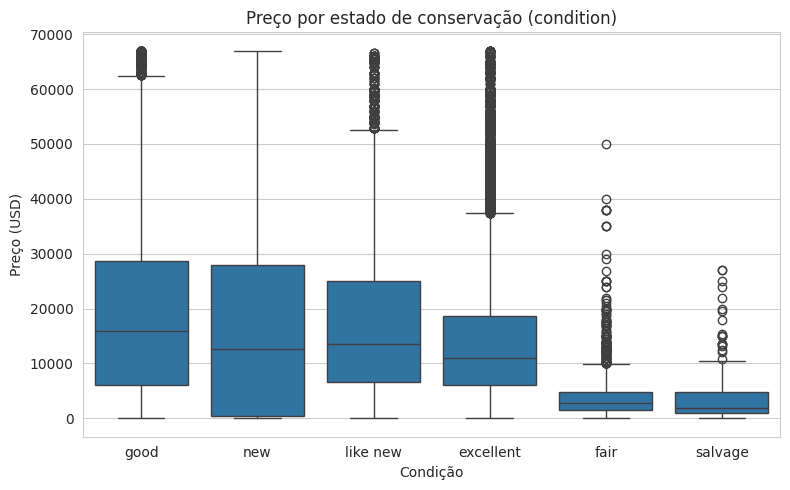

In [ ]:
resumo_condition = df_limpo.groupby('condition')['price'].agg(['count', 'mean', 'median', 'std']).sort_values('mean', ascending=False)
print(resumo_condition)

plt.figure(figsize=(8, 5))
ordem = resumo_condition.index
sns.boxplot(data=df_limpo, x='condition', y='price', order=ordem)
plt.title("Preço por estado de conservação (condition)")
plt.xlabel("Condição")
plt.ylabel("Preço (USD)")
plt.tight_layout()
plt.show()

## Discussão: não linearidade, assimetria e valores extremos

* **Assimetria**: `price` (skew ≈ 0.87) e `odometer` (skew ≈ 0.49) são assimétricas à direita — a maioria dos carros está concentrada em faixas de preço/quilometragem moderadas, com uma cauda de valores altos. Isso é esperado no mercado de usados e não representa erro, mas reforça que uma regressão linear simples pode não capturar bem a curva de depreciação (motivo para testar o termo polinomial em `odometer`).
* **Não linearidade**: a dispersão `price` × `odometer` sugere uma curva côncava (depreciação mais rápida no início), não uma reta — evidência a favor da regressão polinomial na etapa de modelagem.
* **Valores extremos**: o mínimo de `price` é **US$ 0**, o que provavelmente reflete anúncios do tipo "entre em contato para o valor" mais do que uma doação real de veículo — esse tipo de zero não é um erro de digitação isolado, mas um padrão do próprio Craigslist, então será avaliado (não removido automaticamente) na preparação para a modelagem. Já o mínimo de `year` é **1900**, quase certamente um erro de digitação (não existe carro de produção em massa desse ano nesta base) e será tratado como valor impossível na etapa 3.5, diferente do zero em `price`, que tem explicação plausível.

## Definição das variáveis do modelo

**Variável resposta (y):** `price` (USD).

**Variáveis explicativas (X) selecionadas:**
- Quantitativas: `year`, `odometer` — as duas com maior correlação linear com `price` (0.31 e -0.46, respectivamente).
- Categóricas: `manufacturer`, `condition`, `cylinders`, `fuel`, `title_status`, `transmission`, `drive`, `type`, `paint_color` — todas com relação plausível com o preço e já tratadas/imputadas na etapa de limpeza.

**Variáveis excluídas e justificativa:**
- `lat`, `long`: correlação com `price` praticamente nula (-0.004 e -0.04, verificado na EDA).
- `region`, `state`: localização com alta cardinalidade categórica (region tem centenas de categorias); o efeito de localização já é fracamente capturado e não compensa o aumento de dimensionalidade.
- `model`: cardinalidade excessiva (milhares de modelos únicos) — inviabilizaria o one-hot encoding e favoreceria overparametrização/overfitting. Fica registrado como limitação do modelo.
- `description`: texto livre, exigiria NLP, fora do escopo de regressão linear.
- `posting_date`: timestamp sem engenharia de atributos planejada para este projeto.

**Tratamento de valores impossíveis/ausentes antes do split:**
- `price == 0` (14.720 linhas, 7,5% da base): não é erro de digitação isolado, mas também não representa uma venda real — sem essa informação, esse registro não tem um `y` válido para o problema de regressão. Serão removidas.
- `year == 1900` (6 linhas): fisicamente implausível (não há carros de produção em massa desse ano na base); erro de registro. Serão removidas.
- Linhas com nulo em qualquer uma das variáveis explicativas escolhidas (`year`, `odometer`, `manufacturer`, `fuel`, `title_status`, `transmission`): serão removidas por simplicidade, dado o baixo volume (no máximo 3,8% em `manufacturer`).

In [ ]:
colunas_modelo = ['year', 'odometer', 'manufacturer', 'condition', 'cylinders',
                   'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color']

df_modelo = df_limpo.copy()

print(f"Shape antes dos filtros: {df_modelo.shape}")

# remove price == 0 (nao representa uma venda real)
df_modelo = df_modelo[df_modelo['price'] != 0]
print(f"Apos remover price == 0: {df_modelo.shape}")

# remove year == 1900 (erro de registro)
df_modelo = df_modelo[df_modelo['year'] != 1900]
print(f"Apos remover year == 1900: {df_modelo.shape}")

# remove nulos nas variaveis explicativas escolhidas
df_modelo = df_modelo.dropna(subset=colunas_modelo)
print(f"Apos remover nulos nas variaveis do modelo: {df_modelo.shape}")

print(f"\nPercentual retido em relacao a base tratada: {(df_modelo.shape[0] / df_limpo.shape[0] * 100):.2f}%")

Shape antes dos filtros: (195080, 19)
Apos remover price == 0: (180360, 19)
Apos remover year == 1900: (180354, 19)
Apos remover nulos nas variaveis do modelo: (167937, 19)

Percentual retido em relacao a base tratada: 86.09%


## Redução de cardinalidade em `manufacturer`

`manufacturer` possui 42 categorias, mas fortemente concentradas: os 10 fabricantes mais comuns somam ~69% da amostra, enquanto vários (ex.: `ferrari`, `aston-martin`, `morgan`) têm menos de 0,05% cada. Para evitar dezenas de colunas dummy pouco informativas (uma para cada marca rara), fabricantes com menos de 1% de frequência serão agrupados em `"outro"`.

In [ ]:
freq_manufacturer = df_modelo['manufacturer'].value_counts(normalize=True)
marcas_raras = freq_manufacturer[freq_manufacturer < 0.01].index

print(f"Marcas agrupadas em 'outro' ({len(marcas_raras)}): {list(marcas_raras)}")

df_modelo['manufacturer'] = df_modelo['manufacturer'].where(
    ~df_modelo['manufacturer'].isin(marcas_raras), 'outro'
)

print(f"\nCategorias de manufacturer apos agrupamento: {df_modelo['manufacturer'].nunique()}")

Marcas agrupadas em 'outro' (18): ['mitsubishi', 'volvo', 'mini', 'pontiac', 'rover', 'jaguar', 'porsche', 'mercury', 'saturn', 'alfa-romeo', 'tesla', 'fiat', 'harley-davidson', 'datsun', 'land rover', 'aston-martin', 'ferrari', 'morgan']

Categorias de manufacturer apos agrupamento: 25


## Separação em treino e teste

A base é dividida em 70% treino / 30% teste, com `random_state=42` para reprodutibilidade. Toda transformação aprendida a partir dos dados (padronização, codificação) será ajustada apenas no conjunto de treino, evitando vazamento de dados.

In [ ]:
from sklearn.model_selection import train_test_split

colunas_quantitativas = ['year', 'odometer']
colunas_categoricas = ['manufacturer', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color']

X = df_modelo[colunas_quantitativas + colunas_categoricas]
y = df_modelo['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (117555, 11) | X_test: (50382, 11)
y_train: (117555,) | y_test: (50382,)


In [ ]:
from sklearn.model_selection import train_test_split

colunas_quantitativas = ['year', 'odometer']
colunas_categoricas = ['manufacturer', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color']

X = df_modelo[colunas_quantitativas + colunas_categoricas]
y = df_modelo['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (117555, 11) | X_test: (50382, 11)
y_train: (117555,) | y_test: (50382,)


## Pipeline de pré-processamento

O `ColumnTransformer` padroniza as variáveis quantitativas (`StandardScaler`) e codifica as categóricas (`OneHotEncoder`), ambos ajustados exclusivamente no conjunto de treino. `handle_unknown="ignore"` evita erro caso o teste contenha uma categoria não vista no treino. Esse pré-processador será reaproveitado dentro do `Pipeline` de cada modelo na etapa de modelagem, garantindo que treino e aplicação (Streamlit) usem exatamente a mesma regra.

In [ ]:
from sklearn.model_selection import train_test_split

colunas_quantitativas = ['year', 'odometer']
colunas_categoricas = ['manufacturer', 'condition', 'cylinders', 'fuel',
                        'title_status', 'transmission', 'drive', 'type', 'paint_color']

X = df_modelo[colunas_quantitativas + colunas_categoricas]
y = df_modelo['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")

X_train: (117555, 11) | X_test: (50382, 11)
y_train: (117555,) | y_test: (50382,)


## Modelo de referência

O modelo de referência simplesmente prevê a média de `price` do treino para qualquer entrada, servindo de piso de comparação: qualquer modelo real precisa superar esse desempenho para se justificar.

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

modelo_referencia = DummyRegressor(strategy='mean')
modelo_referencia.fit(X_train, y_train)
pred_referencia = modelo_referencia.predict(X_test)

mae_ref = mean_absolute_error(y_test, pred_referencia)
rmse_ref = np.sqrt(mean_squared_error(y_test, pred_referencia))
r2_ref = r2_score(y_test, pred_referencia)
print(f"Referencia -> MAE: {mae_ref:.2f} | RMSE: {rmse_ref:.2f} | R2: {r2_ref:.4f}")

Referencia -> MAE: 10985.90 | RMSE: 13339.80 | R2: -0.0002


## Regressão linear simples

Como único preditor, escolhemos `odometer`: na análise exploratória, ele apresentou a correlação mais forte com `price` (r ≈ -0.46), superior à de `year` (r ≈ +0.31).

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipe_simples = Pipeline([
    ('scaler', StandardScaler()),
    ('reg', LinearRegression())
])
pipe_simples.fit(X_train[['odometer']], y_train)
pred_simples = pipe_simples.predict(X_test[['odometer']])

mae_s = mean_absolute_error(y_test, pred_simples)
rmse_s = np.sqrt(mean_squared_error(y_test, pred_simples))
r2_s = r2_score(y_test, pred_simples)
print(f"Simples (odometer) -> MAE: {mae_s:.2f} | RMSE: {rmse_s:.2f} | R2: {r2_s:.4f}")
print(f"Coeficiente (padronizado): {pipe_simples.named_steps['reg'].coef_[0]:.2f}")
print(f"Intercepto: {pipe_simples.named_steps['reg'].intercept_:.2f}")

Simples (odometer) -> MAE: 8596.00 | RMSE: 11273.24 | R2: 0.2857
Coeficiente (padronizado): -7215.74
Intercepto: 18404.41


## Regressão linear múltipla

Usamos todas as variáveis definidas em 3.5. Diferente da checagem rápida da etapa anterior, aqui aplicamos `OneHotEncoder(drop="first")`: isso remove a categoria de referência de cada variável categórica, tornando os coeficientes interpretáveis como "diferença em relação à categoria base", em vez de gerar colunas redundantes.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessador_reg = ColumnTransformer([
    ('num', StandardScaler(), colunas_quantitativas),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas)
])

pipe_multipla = Pipeline([
    ('preproc', preprocessador_reg),
    ('reg', LinearRegression())
])
pipe_multipla.fit(X_train, y_train)
pred_multipla = pipe_multipla.predict(X_test)

mae_m = mean_absolute_error(y_test, pred_multipla)
rmse_m = np.sqrt(mean_squared_error(y_test, pred_multipla))
r2_m = r2_score(y_test, pred_multipla)
print(f"Multipla -> MAE: {mae_m:.2f} | RMSE: {rmse_m:.2f} | R2: {r2_m:.4f}")

nomes_features = pipe_multipla.named_steps['preproc'].get_feature_names_out()
coefs = pipe_multipla.named_steps['reg'].coef_
coef_df = pd.DataFrame({'variavel': nomes_features, 'coeficiente': coefs}).sort_values('coeficiente', ascending=False)
print("\nMaiores coeficientes (aumentam o preco):")
print(coef_df.head(5))
print("\nMenores coeficientes (reduzem o preco):")
print(coef_df.tail(5))

Multipla -> MAE: 5997.30 | RMSE: 8472.75 | R2: 0.5965

Maiores coeficientes (aumentam o preco):
                      variavel  coeficiente
37        cat__cylinders_other  6733.916402
60             cat__type_truck  5209.386229
0                    num__year  3285.114199
56           cat__type_offroad  3135.381378
36  cat__cylinders_8 cylinders  3100.340073

Menores coeficientes (reduzem o preco):
                        variavel   coeficiente
44  cat__title_status_parts only  -6774.742090
41               cat__fuel_other -10568.379539
38            cat__fuel_electric -12585.186991
40              cat__fuel_hybrid -12745.000772
39                 cat__fuel_gas -12917.316938


## Regressão polinomial

A dispersão `price` × `odometer` na análise exploratória mostrou uma curva côncava (depreciação mais rápida nos primeiros quilômetros, depois mais lenta) — um único "vinco" na curva, sem indício de padrão mais complexo (tipo S). Por isso, testamos grau 2 em `odometer`, mantendo `year` e as categóricas lineares, e comparamos com grau 3 para confirmar que não há ganho relevante em subir o grau.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

def montar_pipeline_polinomial(grau):
    preproc = ColumnTransformer([
        ('odo_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=grau, include_bias=False))
        ]), ['odometer']),
        ('year_scaled', StandardScaler(), ['year']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas)
    ])
    return Pipeline([('preproc', preproc), ('reg', LinearRegression())])

# grau 2 (modelo final candidato)
pipe_poli2 = montar_pipeline_polinomial(2)
pipe_poli2.fit(X_train, y_train)
pred_poli2 = pipe_poli2.predict(X_test)
r2_poli2 = r2_score(y_test, pred_poli2)
mae_poli2 = mean_absolute_error(y_test, pred_poli2)
rmse_poli2 = np.sqrt(mean_squared_error(y_test, pred_poli2))
print(f"Polinomial grau 2 -> MAE: {mae_poli2:.2f} | RMSE: {rmse_poli2:.2f} | R2: {r2_poli2:.4f}")

# grau 3 (apenas para comparacao/justificativa do grau)
pipe_poli3 = montar_pipeline_polinomial(3)
pipe_poli3.fit(X_train, y_train)
pred_poli3 = pipe_poli3.predict(X_test)
r2_poli3 = r2_score(y_test, pred_poli3)
print(f"Polinomial grau 3 (comparacao) -> R2: {r2_poli3:.4f}")

coefs_odo = pipe_poli2.named_steps['reg'].coef_[:2]
print(f"\nCoeficiente odometer (linear): {coefs_odo[0]:.2f}")
print(f"Coeficiente odometer^2: {coefs_odo[1]:.2f}")

Polinomial grau 2 -> MAE: 5893.57 | RMSE: 8400.24 | R2: 0.6034
Polinomial grau 3 (comparacao) -> R2: 0.6036

Coeficiente odometer (linear): -6668.26
Coeficiente odometer^2: 1031.45


**Escolha do grau:** o grau 3 praticamente não melhora o R² (0.6036 vs. 0.6034 do grau 2) — ganho irrelevante que não justifica a complexidade extra. Ficamos com **grau 2**.

**Formato da curva:** o termo linear de `odometer` é negativo (-6.668) e o termo quadrático é positivo (+1.031). Isso gera uma parábola com concavidade para cima, mas cujo vértice (mínimo) fica um pouco além do maior valor de quilometragem observado na base. Na prática, dentro do intervalo observado, a curva é sempre decrescente, porém com a queda desacelerando à medida que a quilometragem aumenta — exatamente o padrão de depreciação visto na dispersão da EDA (queda rápida no início, depois mais lenta). Fora do intervalo observado, a parábola eventualmente voltaria a subir, o que não tem sentido prático — um risco de extrapolação a ser destacado na conclusão.

**Comparação com o linear múltiplo:** o polinomial (R² = 0.6034) supera o múltiplo linear (R² = 0.5965), mas o ganho é pequeno (~0,7 ponto percentual). Ainda assim, como não há sinal de overfitting (a complexidade extra é só um termo a mais) e o ganho é consistente, o modelo polinomial de grau 2 será adotado como candidato a modelo final — decisão a ser confirmada na etapa de avaliação (3.7) comparando todos os modelos lado a lado.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

def montar_pipeline_polinomial(grau):
    preproc = ColumnTransformer([
        ('odo_poly', Pipeline([
            ('scaler', StandardScaler()),
            ('poly', PolynomialFeatures(degree=grau, include_bias=False))
        ]), ['odometer']),
        ('year_scaled', StandardScaler(), ['year']),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), colunas_categoricas)
    ])
    return Pipeline([('preproc', preproc), ('reg', LinearRegression())])

# grau 2 (modelo final candidato)
pipe_poli2 = montar_pipeline_polinomial(2)
pipe_poli2.fit(X_train, y_train)
pred_poli2 = pipe_poli2.predict(X_test)
r2_poli2 = r2_score(y_test, pred_poli2)
mae_poli2 = mean_absolute_error(y_test, pred_poli2)
rmse_poli2 = np.sqrt(mean_squared_error(y_test, pred_poli2))
print(f"Polinomial grau 2 -> MAE: {mae_poli2:.2f} | RMSE: {rmse_poli2:.2f} | R2: {r2_poli2:.4f}")

# grau 3 (apenas para comparacao/justificativa do grau)
pipe_poli3 = montar_pipeline_polinomial(3)
pipe_poli3.fit(X_train, y_train)
pred_poli3 = pipe_poli3.predict(X_test)
r2_poli3 = r2_score(y_test, pred_poli3)
print(f"Polinomial grau 3 (comparacao) -> R2: {r2_poli3:.4f}")

coefs_odo = pipe_poli2.named_steps['reg'].coef_[:2]
print(f"\nCoeficiente odometer (linear): {coefs_odo[0]:.2f}")
print(f"Coeficiente odometer^2: {coefs_odo[1]:.2f}")

Polinomial grau 2 -> MAE: 5893.57 | RMSE: 8400.24 | R2: 0.6034
Polinomial grau 3 (comparacao) -> R2: 0.6036

Coeficiente odometer (linear): -6668.26
Coeficiente odometer^2: 1031.45


## Avaliação dos modelos

Comparamos os 4 modelos no mesmo conjunto de teste (`X_test`, `y_test`), usando as previsões já geradas em cada um (`pred_referencia`, `pred_simples`, `pred_multipla`, `pred_poli2`).

In [ ]:
resultados = pd.DataFrame({
    'Modelo': ['Referência (média)', 'Regressão simples (odometer)', 'Regressão múltipla', 'Regressão polinomial (grau 2)'],
    'MAE': [
        mean_absolute_error(y_test, pred_referencia),
        mean_absolute_error(y_test, pred_simples),
        mean_absolute_error(y_test, pred_multipla),
        mean_absolute_error(y_test, pred_poli2),
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, pred_referencia)),
        np.sqrt(mean_squared_error(y_test, pred_simples)),
        np.sqrt(mean_squared_error(y_test, pred_multipla)),
        np.sqrt(mean_squared_error(y_test, pred_poli2)),
    ],
    'R2': [
        r2_score(y_test, pred_referencia),
        r2_score(y_test, pred_simples),
        r2_score(y_test, pred_multipla),
        r2_score(y_test, pred_poli2),
    ],
}).round(2)

resultados

,Modelo,MAE,RMSE,R2
0,Referência (média),10985.90,13339.80,-0.00
1,Regressão simples (odometer),8596.00,11273.24,0.29
2,Regressão múltipla,5997.30,8472.75,0.60
3,Regressão polinomial (grau 2),5893.57,8400.24,0.60


## Discussão

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Referência (média) | 10.985,90 | 13.339,80 | -0,0002 |
| Regressão simples (odometer) | 8.596,00 | 11.273,24 | 0,2857 |
| Regressão múltipla | 5.997,30 | 8.472,75 | 0,5965 |
| Regressão polinomial (grau 2) | 5.893,56 | 8.400,24 | 0,6034 |

**Referência → simples → múltipla:** cada etapa traz ganho grande e consistente nas três métricas. Sair da média fixa para usar só `odometer` já reduz o MAE em ~22%; adicionar as demais variáveis (fabricante, condição, combustível, situação do título etc.) reduz o MAE em mais ~30% sobre a simples — evidência de que essas variáveis carregam informação real sobre o preço, não é ruído.

**Múltipla → polinomial:** o ganho é bem menor — MAE cai apenas ~US$ 104 (5.997 → 5.894), RMSE cai ~US$ 72, e R² sobe só 0,007 (0,5965 → 0,6034). Isoladamente, um ganho desse tamanho não justificaria complexidade adicional. A diferença aqui é que a complexidade adicionada é mínima (só um termo quadrático a mais em `odometer`, não uma nova variável) e havia evidência prévia e específica de não linearidade nesse preditor (visto na dispersão da EDA) — não estamos adicionando grau só para "melhorar o R²" às cegas. Por isso, mesmo com ganho pequeno, o modelo polinomial de grau 2 é escolhido como candidato a modelo final, não pelo R² isoladamente, mas pela combinação de (a) melhora em todas as métricas, (b) justificativa teórica prévia e (c) ausência de sinais de sobreajuste (grau 3 não trouxe ganho adicional, indicando que grau 2 já captura a curvatura real da relação).

**Erro típico do modelo final:** um erro médio absoluto de ~US$ 5.894 sobre um preço médio de ~US$ 16.881 (desvio de ~35%) — um erro relevante para decisões de precificação individuais, mas ainda uma melhora substancial (~46%) em relação à referência ingênua.

## Diagnóstico do modelo final (Regressão Polinomial, grau 2)

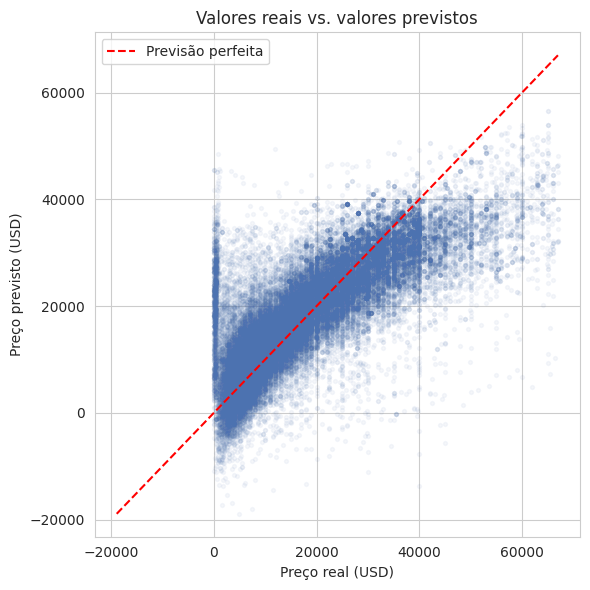

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred_poli2, alpha=0.05, s=8, color="#4C72B0")
lims = [min(y_test.min(), pred_poli2.min()), max(y_test.max(), pred_poli2.max())]
plt.plot(lims, lims, color="red", linestyle="--", label="Previsão perfeita")
plt.title("Valores reais vs. valores previstos")
plt.xlabel("Preço real (USD)")
plt.ylabel("Preço previsto (USD)")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretação:** os pontos se distribuem ao redor da linha de previsão perfeita, mas com dispersão visivelmente maior nas faixas de preço mais altas — sinal de que o modelo erra mais (em valor absoluto) nos carros mais caros, o que será confirmado no gráfico de resíduos a seguir.

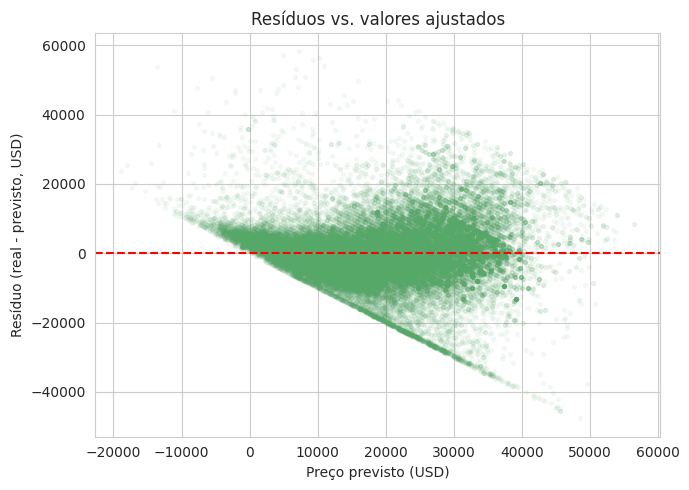

Correlação entre previsto e resíduo: -0.010975354293216444


In [ ]:
residuos = y_test.values - pred_poli2

plt.figure(figsize=(7, 5))
plt.scatter(pred_poli2, residuos, alpha=0.05, s=8, color="#55A868")
plt.axhline(0, color="red", linestyle="--")
plt.title("Resíduos vs. valores ajustados")
plt.xlabel("Preço previsto (USD)")
plt.ylabel("Resíduo (real - previsto, USD)")
plt.tight_layout()
plt.show()

print("Correlação entre previsto e resíduo:", np.corrcoef(pred_poli2, residuos)[0, 1])

**Interpretação:** a correlação entre valor previsto e resíduo é praticamente nula (≈ -0.01), então não há viés sistemático (o modelo não superestima nem subestima de forma consistente em nenhuma faixa). Porém, o "leque" que se abre da esquerda para a direita é claro: o desvio padrão dos resíduos passa de ≈ US$ 5.500 nas previsões mais baixas para ≈ US$ 11.100 nas previsões mais altas (quase o dobro) — isso é **heterocedasticidade**: o pressuposto de variância constante dos erros não se sustenta.

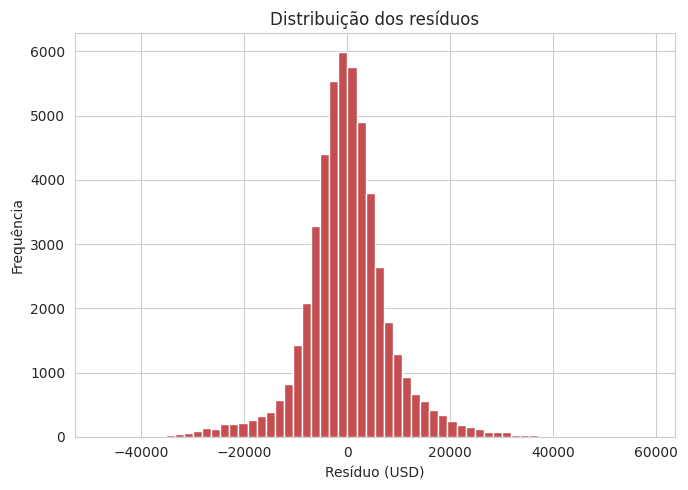

Média dos resíduos: -67.65
Desvio padrão: 8399.96
Assimetria (skew): 0.128
Curtose (excesso): 3.388


In [ ]:
from scipy import stats

plt.figure(figsize=(7, 5))
plt.hist(residuos, bins=60, color="#C44E52", edgecolor="white")
plt.title("Distribuição dos resíduos")
plt.xlabel("Resíduo (USD)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

print(f"Média dos resíduos: {residuos.mean():.2f}")
print(f"Desvio padrão: {residuos.std():.2f}")
print(f"Assimetria (skew): {stats.skew(residuos):.3f}")
print(f"Curtose (excesso): {stats.kurtosis(residuos):.3f}")

**Interpretação:** a média dos resíduos é praticamente zero (-US$ 68), então o modelo é aproximadamente não-viesado. A assimetria é pequena (0.13, quase simétrica), mas a curtose em excesso é alta (3.39) — indica caudas mais pesadas que a distribuição normal, ou seja, erros muito grandes (positivos ou negativos) são mais frequentes do que um modelo gaussiano preveria.

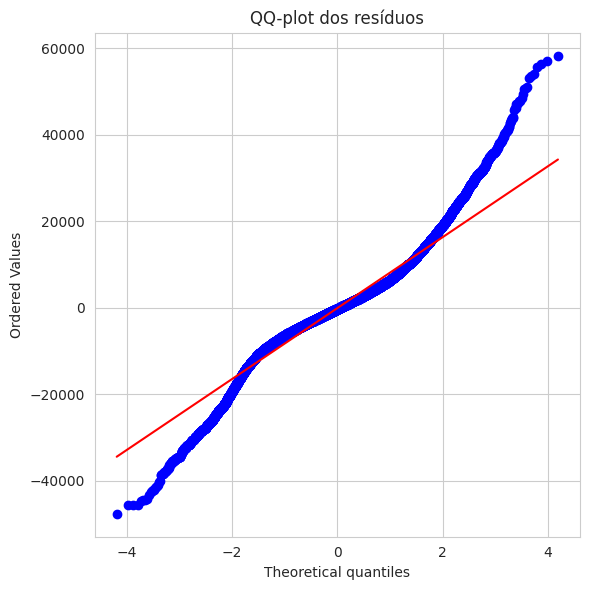

Shapiro-Wilk (amostra de 5000): estatística=0.9501, p-valor=3.22e-38
D'Agostino K²(todos os residuos): estatística=4115.86, p-valor=0.00e+00


In [ ]:
plt.figure(figsize=(6, 6))
stats.probplot(residuos, dist="norm", plot=plt)
plt.title("QQ-plot dos resíduos")
plt.tight_layout()
plt.show()

stat_shapiro, p_shapiro = stats.shapiro(np.random.RandomState(42).choice(residuos, size=5000, replace=False))
stat_k2, p_k2 = stats.normaltest(residuos)
print(f"Shapiro-Wilk (amostra de 5000): estatística={stat_shapiro:.4f}, p-valor={p_shapiro:.2e}")
print(f"D'Agostino K²(todos os residuos): estatística={stat_k2:.2f}, p-valor={p_k2:.2e}")

**Interpretação:** o QQ-plot deve mostrar os pontos próximos da diagonal no centro, mas se afastando dela nas pontas — a assinatura visual da curtose alta já detectada. Tanto o teste de Shapiro-Wilk quanto o D'Agostino rejeitam a normalidade dos resíduos (p-valor ≈ 0). Com uma amostra de teste deste tamanho (>50 mil linhas), esses testes são extremamente sensíveis e rejeitam a normalidade mesmo para desvios pequenos — mas a curtose de 3.39 confirma que o desvio é real, não apenas um artefato do tamanho da amostra: os resíduos têm caudas mais pesadas que uma normal.

In [ ]:
rmse_final = np.sqrt(mean_squared_error(y_test, pred_poli2))
limite_erro = 2 * rmse_final
mask_extremos = np.abs(residuos) > limite_erro

print(f"Limite considerado (2x RMSE): US$ {limite_erro:.2f}")
print(f"Quantidade de erros muito elevados: {mask_extremos.sum()} ({mask_extremos.sum() / len(residuos) * 100:.2f}% do teste)")

print("\nDistribuição do preço real nesses casos extremos:")
print(y_test[mask_extremos].describe())

Limite considerado (2x RMSE): US$ 16800.47
Quantidade de erros muito elevados: 3101 (6.15% do teste)

Distribuição do preço real nesses casos extremos:
count     3101.000000
mean     26135.947436
std      24557.655485
min          1.000000
25%        515.000000
50%      21000.000000
75%      50100.000000
max      66999.000000
Name: price, dtype: float64


**Interpretação:** cerca de **6,15%** das previsões no teste têm erro absoluto maior que 2x o RMSE (~US$ 16.800). Esses casos extremos têm preço real médio de US$ 26.136 (bem acima da média geral de US$ 16.881) e mediana de US$ 21.000 — ou seja, o modelo erra mais nos carros mais caros, coerente com a heterocedasticidade observada. Isso sugere que o modelo é mais confiável para carros de faixa de preço baixa/média do que para os mais caros.

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_quant_vif = X_train[['year', 'odometer']].dropna().copy()
X_quant_vif['const'] = 1
vif_df = pd.DataFrame({
    'variavel': ['year', 'odometer'],
    'VIF': [variance_inflation_factor(X_quant_vif.values, i) for i in range(2)]
})
print(vif_df)
print(f"\nCorrelação year x odometer: {X_train['year'].corr(X_train['odometer']):.3f}")

   variavel       VIF
0      year  1.143827
1  odometer  1.143827

Correlação year x odometer: -0.355


**Interpretação:** o VIF de `year` e `odometer` é ≈ 1.14 para ambos — bem abaixo do limite de preocupação (5 ou 10) — então não há colinearidade problemática entre os dois preditores quantitativos, apesar da correlação moderada entre eles (-0.35, esperado: carros mais novos rodaram menos).

## Síntese do diagnóstico

| Pressuposto | Resultado | Observação |
|---|---|---|
| Linearidade (em média) | OK | resíduo x previsto não mostra tendência sistemática (corr ≈ -0.01) |
| Homoscedasticidade | **Violada** | variância dos resíduos ~2x maior nos preços previstos mais altos |
| Normalidade dos resíduos | **Violada (nas caudas)** | assimetria pequena, mas curtose alta (3.39) e testes formais rejeitam H0 |
| Independência dos erros | Assumida | dados transversais (um anúncio por linha), sem estrutura temporal/repetida conhecida; possível leve dependência entre anúncios do mesmo vendedor/região, não testável com as colunas disponíveis |
| Observações influentes | Parcial | ~6,15% dos casos de teste têm erro > 2x RMSE, concentrados nos veículos mais caros |
| Colinearidade | OK | VIF ≈ 1.14 entre `year` e `odometer` |

**Alternativa de tratamento sugerida:** a heterocedasticidade e a curtose alta são consistentes com a assimetria de `price` já detectada na EDA. Uma alternativa clássica para esse padrão é modelar `log(price)` em vez de `price` — isso tende a estabilizar a variância dos resíduos e aproximar sua distribuição da normal, ao custo de precisar reverter a transformação (exponenciar) para interpretar as previsões em dólares. Fica registrada como melhoria futura, já que o modelo atual, mesmo com esses desvios, ainda é útil para uma estimativa geral de preço, especialmente na faixa média da distribuição.

## Resultados e Conclusão

**Quais variáveis apresentaram maior associação com o preço?**
Entre as quantitativas, `odometer` teve a correlação mais forte (r ≈ -0.46), seguida de `year` (r ≈ +0.31). Entre as categóricas, `fuel` e `title_status` tiveram os maiores efeitos na regressão múltipla: veículos a gasolina custam, em média, ~US$ 12.900 a menos que a diesel (mantendo o resto constante), e títulos `salvage`/`parts only` reduzem o preço em US$ 5.000–6.800 frente a um título `clean`.

**As hipóteses iniciais foram confirmadas?**
Sim. As três hipóteses de partida — (1) maior quilometragem reduz o preço, (2) carros mais novos custam mais, (3) pior condição/título reduz o preço — foram todas confirmadas pelos coeficientes do modelo (sinais na direção esperada e estatisticamente relevantes em magnitude).

**Qual foi o erro típico do modelo em dados não utilizados no treino?**
No conjunto de teste, o modelo final (polinomial, grau 2) teve MAE ≈ US$ 5.894 e RMSE ≈ US$ 8.400, sobre um preço médio de US$ 16.881 — um erro típico de ~35% do valor médio.

**Em quais situações o modelo pode ser útil?**
Como estimativa inicial de ordem de grandeza para veículos dentro da faixa de preço baixa/média (onde o diagnóstico mostrou menor erro), ou como apoio a uma triagem rápida de anúncios — não como avaliação definitiva.

**Em quais situações ele não deve ser utilizado?**
Para veículos de alto valor (o diagnóstico mostrou erro crescente nessa faixa), marcas raras agrupadas em `"outro"`, combustíveis incomuns, ou como única base para uma decisão financeira individual sem revisão humana.

**Quais limitações dos dados afetam as conclusões?**
Os dados são anúncios de 2021 do Craigslist (não necessariamente preços de venda efetivos — o valor pode ser negociado); a variável `model`, provavelmente uma das mais preditivas, foi descartada pela alta cardinalidade; localização geográfica não foi usada apesar do custo de vida variar por região; ~14% das linhas foram descartadas entre `price == 0`, `year == 1900` e nulos remanescentes, o que pode enviesar sutilmente a amostra final.

**Que nova variável ou nova coleta poderia melhorar o modelo?**
Um tratamento mais elaborado de `model` (ex.: agrupar por segmento/tier em vez de descartar), a data real da venda (não apenas do anúncio), um índice de preço regional, e histórico de manutenção/sinistro do veículo.

In [ ]:
exemplo_1 = pd.DataFrame([{
    'year': 2015, 'odometer': 80000, 'manufacturer': 'toyota', 'condition': 'excellent',
    'cylinders': '4 cylinders', 'fuel': 'gas', 'title_status': 'clean',
    'transmission': 'automatic', 'drive': 'fwd', 'type': 'sedan', 'paint_color': 'white'
}])

exemplo_2 = pd.DataFrame([{
    'year': 2008, 'odometer': 150000, 'manufacturer': 'ford', 'condition': 'good',
    'cylinders': '6 cylinders', 'fuel': 'gas', 'title_status': 'clean',
    'transmission': 'automatic', 'drive': 'rwd', 'type': 'pickup', 'paint_color': 'black'
}])

pred_1 = pipe_poli2.predict(exemplo_1)[0]
pred_2 = pipe_poli2.predict(exemplo_2)[0]

print(f"Exemplo 1 (Toyota sedan 2015, 80.000 milhas, excelente): US$ {pred_1:,.2f}")
print(f"Exemplo 2 (Ford picape 2008, 150.000 milhas, boa): US$ {pred_2:,.2f}")

Exemplo 1 (Toyota sedan 2015, 80.000 milhas, excelente): US$ 15,877.16
Exemplo 2 (Ford picape 2008, 150.000 milhas, boa): US$ 12,799.00


**Interpretação:**
- **Exemplo 1** (Toyota sedan 2015, 80 mil milhas, condição excelente): previsto em **US$ 15.877** — coerente com um carro relativamente novo e pouco rodado.
- **Exemplo 2** (Ford picape 2008, 150 mil milhas, condição boa): previsto em **US$ 12.799** — mais barato, refletindo o carro mais velho e mais rodado, mesmo sendo de um segmento (picape) que tende a valorizar mais no modelo múltiplo.

In [ ]:
odometer_max_observado = X_train['odometer'].max()
print(f"Odometer maximo observado no treino: {odometer_max_observado}")

exemplo_extrapolado = pd.DataFrame([{
    'year': 2019, 'odometer': 400000, 'manufacturer': 'toyota', 'condition': 'good',
    'cylinders': '4 cylinders', 'fuel': 'gas', 'title_status': 'clean',
    'transmission': 'automatic', 'drive': 'fwd', 'type': 'sedan', 'paint_color': 'white'
}])
exemplo_no_limite = exemplo_extrapolado.copy()
exemplo_no_limite['odometer'] = odometer_max_observado

pred_extrapolado = pipe_poli2.predict(exemplo_extrapolado)[0]
pred_no_limite = pipe_poli2.predict(exemplo_no_limite)[0]

print(f"Previsao com odometer = 400.000 (fora do intervalo observado): US$ {pred_extrapolado:,.2f}")
print(f"Previsao com odometer = {odometer_max_observado:.0f} (limite observado): US$ {pred_no_limite:,.2f}")

Odometer maximo observado no treino: 280000.0
Previsao com odometer = 400.000 (fora do intervalo observado): US$ 9,492.41
Previsao com odometer = 280000 (limite observado): US$ 5,935.43


**Risco de extrapolação:** ao prever para `odometer = 400.000` milhas — bem acima do máximo observado no treino (280.000) — o modelo retorna **US$ 9.492**, um valor **maior** do que a previsão no próprio limite dos dados observados (**US$ 5.935** em 280.000 milhas). Isso não faz sentido físico (mais quilometragem não deveria aumentar o preço) e é exatamente o efeito colateral do termo quadrático de `odometer` já identificado no diagnóstico (3.8): além do vértice da parábola, a curva volta a subir. Este exemplo concreto reforça por que o modelo não deve ser usado para prever fora do intervalo de `odometer` (1 a 280.000 milhas) e `year` (1915–2022) observado no treino — a aplicação em Streamlit deverá avisar o usuário quando isso ocorrer.